<a href="https://colab.research.google.com/github/rodriwsz/Implementing-CSV-in-Python-API-1-2026/blob/main/API_RodrigoAzevedo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
data = {'coluna 1':[1.5,2.0,3.1,4.2,5.1],
        'coluna 2':[10.0,21.0,30.0,15.0,31.0],
        'coluna 3':[0,1,0,1,0],
        'coluna 4':[1,0,1,1,1],
        'coluna 5':[20.5,25.5,22.0,27.0,23.0],
        }

In [ ]:
df = pd.DataFrame(data)

In [ ]:
print(df)

   coluna 1  coluna 2  coluna 3  coluna 4  coluna 5
0       1.5      10.0         0         1      20.5
1       2.0      21.0         1         0      25.5
2       3.1      30.0         0         1      22.0
3       4.2      15.0         1         1      27.0
4       5.1      31.0         0         1      23.0


In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
origem = '/content/drive/My Drive/Data/COMEXSTAT/'

In [ ]:
arquivo_1 = origem + 'EXP_2025.csv'
arquivo_2 = origem + 'EXP_2026.csv'
ncm = origem + 'NCM.csv'
pais = origem + 'PAIS.csv'
urf = origem + 'URF.csv'
via = origem + 'VIA.csv'

In [ ]:
exp25 = pd.read_csv(arquivo_1,low_memory=False,sep=';', encoding='UTF-8')
exp26 = pd.read_csv(arquivo_2,low_memory=False,sep=';', encoding='UTF-8')
expncm = pd.read_csv(ncm,low_memory=False,sep=';', encoding='latin1')
exppais = pd.read_csv(pais,low_memory=False,sep=';', encoding='UTF-8')
expurf = pd.read_csv(urf,low_memory=False,sep=';', encoding='latin1')
expvias = pd.read_csv(via,low_memory=False,sep=';', encoding='latin1')

In [ ]:
expncm.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13730 entries, 0 to 13729
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CO_NCM          13730 non-null  int64  
 1   CO_UNID         13730 non-null  int64  
 2   CO_SH6          13730 non-null  int64  
 3   CO_PPE          13426 non-null  float64
 4   CO_PPI          13426 non-null  float64
 5   CO_FAT_AGREG    13708 non-null  float64
 6   CO_CUCI_ITEM    13730 non-null  object 
 7   CO_CGCE_N3      13730 non-null  int64  
 8   CO_SIIT         13426 non-null  float64
 9   CO_ISIC_CLASSE  13730 non-null  int64  
 10  CO_EXP_SUBSET   13424 non-null  float64
 11  NO_NCM_POR      13730 non-null  object 
 12  NO_NCM_ESP      13730 non-null  object 
 13  NO_NCM_ING      13730 non-null  object 
dtypes: float64(5), int64(5), object(4)
memory usage: 1.5+ MB


In [ ]:
exp_final = pd.concat([exp25,exp26], ignore_index=True)
exp_final = exp_final.merge(exppais[['CO_PAIS', 'NO_PAIS']], on='CO_PAIS', how='left')

In [ ]:
exp_final.head(5)

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,NO_PAIS
0,2025,8,71039900,19,687,RS,4,817700,61690,13,203,El Salvador
1,2025,12,2071412,10,741,SC,1,817800,83835,83835,111324,Singapura
2,2025,11,33059000,10,767,SP,4,817600,792,753,22012,Suíça
3,2025,11,56031330,10,845,SP,7,1017701,2437,2437,8458,Uruguai
4,2025,6,21069090,10,365,SP,1,817800,4800,4800,17304,Indonésia


In [ ]:
mes_map = {
    1: 'Janeiro',
    2: 'Fevereiro',
    3: 'Março',
    4: 'Abril',
    5: 'Maio',
    6: 'Junho',
    7: 'Julho',
    8: 'Agosto',
    9: 'Setembro',
    10: 'Outubro',
    11: 'Novembro',
    12: 'Dezembro'
}

# Apply a function to create NO_MES based on both CO_MES and CO_ANO
exp_final['NO_MES'] = exp_final.apply(lambda row: f"{mes_map[row['CO_MES']]}, {row['CO_ANO']}", axis=1)
display(exp_final)

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,NO_PAIS,NO_MES
0,2025,8,71039900,19,687,RS,4,817700,61690,13,203,El Salvador,"Agosto, 2025"
1,2025,12,2071412,10,741,SC,1,817800,83835,83835,111324,Singapura,"Dezembro, 2025"
2,2025,11,33059000,10,767,SP,4,817600,792,753,22012,Suíça,"Novembro, 2025"
3,2025,11,56031330,10,845,SP,7,1017701,2437,2437,8458,Uruguai,"Novembro, 2025"
4,2025,6,21069090,10,365,SP,1,817800,4800,4800,17304,Indonésia,"Junho, 2025"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1835304,2026,1,38276400,10,476,PA,1,217800,10,10,3430,"Marshall, Ilhas","Janeiro, 2026"
1835305,2026,1,90278999,11,301,ES,1,727600,1,0,281,Grécia,"Janeiro, 2026"
1835306,2026,1,9012100,10,573,RJ,1,717600,6,6,180,Países Baixos (Holanda),"Janeiro, 2026"
1835307,2026,1,84149039,10,158,MG,4,817600,100,100,47481,Chile,"Janeiro, 2026"


In [ ]:
exp_final['TOTAL_KG'] = exp_final.groupby('CO_MES')['KG_LIQUIDO'].transform('sum')
display(exp_final)

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,NO_PAIS,NO_MES,TOTAL_KG
0,2025,8,71039900,19,687,RS,4,817700,61690,13,203,El Salvador,"Agosto, 2025",81355786963
1,2025,12,2071412,10,741,SC,1,817800,83835,83835,111324,Singapura,"Dezembro, 2025",77150503445
2,2025,11,33059000,10,767,SP,4,817600,792,753,22012,Suíça,"Novembro, 2025",68137471881
3,2025,11,56031330,10,845,SP,7,1017701,2437,2437,8458,Uruguai,"Novembro, 2025",68137471881
4,2025,6,21069090,10,365,SP,1,817800,4800,4800,17304,Indonésia,"Junho, 2025",74015443872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1835304,2026,1,38276400,10,476,PA,1,217800,10,10,3430,"Marshall, Ilhas","Janeiro, 2026",121771651513
1835305,2026,1,90278999,11,301,ES,1,727600,1,0,281,Grécia,"Janeiro, 2026",121771651513
1835306,2026,1,9012100,10,573,RJ,1,717600,6,6,180,Países Baixos (Holanda),"Janeiro, 2026",121771651513
1835307,2026,1,84149039,10,158,MG,4,817600,100,100,47481,Chile,"Janeiro, 2026",121771651513


In [ ]:
monthly_total_kg = exp_final.groupby('NO_MES')['KG_LIQUIDO'].sum().reset_index()

# Create a reverse map for month names to numbers
reverse_mes_map = {v: k for k, v in mes_map.items()}

# Function to create a sortable key from 'NO_MES'
def get_sort_key(row):
    month_name, year = row['NO_MES'].split(', ')
    month_num = reverse_mes_map[month_name]
    return int(year) * 100 + month_num

# Apply the function to create the sort key and sort the DataFrame
monthly_total_kg['sort_key'] = monthly_total_kg.apply(get_sort_key, axis=1)
monthly_total_kg = monthly_total_kg.sort_values(by='sort_key').drop(columns='sort_key').reset_index(drop=True)

display(monthly_total_kg)

,NO_MES,KG_LIQUIDO
0,"Janeiro, 2025",60584476836
1,"Fevereiro, 2025",51624629314
2,"Março, 2025",65011929332
3,"Abril, 2025",69341819195
4,"Maio, 2025",74335768570
5,"Junho, 2025",74015443872
6,"Julho, 2025",81820666079
7,"Agosto, 2025",81355786963
8,"Setembro, 2025",75759474757
9,"Outubro, 2025",80689691197


In [ ]:
monthly_total_kg_transposed = monthly_total_kg.set_index('NO_MES').transpose()
monthly_total_kg_transposed.index = ['TOTAL_KG'] # Rename the index to reflect the content
display(monthly_total_kg_transposed)

NO_MES,"Janeiro, 2025","Fevereiro, 2025","Março, 2025","Abril, 2025","Maio, 2025","Junho, 2025","Julho, 2025","Agosto, 2025","Setembro, 2025","Outubro, 2025","Novembro, 2025","Dezembro, 2025","Janeiro, 2026"
TOTAL_KG,60584476836,51624629314,65011929332,69341819195,74335768570,74015443872,81820666079,81355786963,75759474757,80689691197,68137471881,77150503445,61187174677


/tmp/ipykernel_255/1384972091.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='NO_MES', y='TOTAL_KG_BILLIONS', data=monthly_data, palette='viridis')


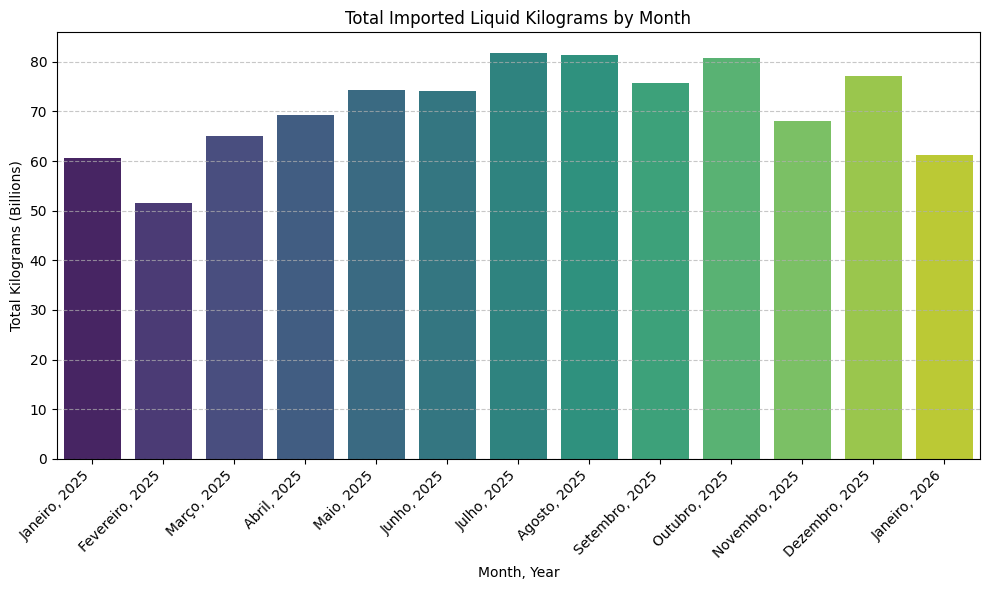

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
monthly_data = monthly_total_kg_transposed.transpose().reset_index()
monthly_data.columns = ['NO_MES', 'TOTAL_KG']

# Convert TOTAL_KG to billions for better readability on the y-axis
monthly_data['TOTAL_KG_BILLIONS'] = monthly_data['TOTAL_KG'] / 1_000_000_000

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='NO_MES', y='TOTAL_KG_BILLIONS', data=monthly_data, palette='viridis')
plt.title('Total Imported Liquid Kilograms by Month')
plt.xlabel('Month, Year')
plt.ylabel('Total Kilograms (Billions)') # Updated y-axis label
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()